In [17]:
import pandas, matplotlib_venn, matplotlib

In [4]:
a = pandas.read_csv('deseq2.txt', sep='\t')
a

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,ensembl_id,gene_name,biotype,description2,medianTPM_WT,medianTPM_HET
ENSG00000206195,2125.950077,8.364166,0.269284,1666.887104,0.000000e+00,0.000000e+00,ENSG00000206195,DUXAP8,lncRNA,double homeobox A pseudogene 8,0.907104,227.371823
ENSG00000222036,1761.313071,9.107035,0.342612,1884.094656,0.000000e+00,0.000000e+00,ENSG00000222036,POTEM,protein_coding,POTE ankyrin domain family member M,0.063923,33.159477
ENSG00000274827,1248.271326,10.956396,0.738978,1114.820318,1.985147e-244,7.192849e-241,ENSG00000274827,LINC01297,lncRNA,long intergenic non-protein coding RNA 1297,0.023911,37.804184
ENSG00000101680,1953.637473,7.479655,0.238034,1112.744468,5.609987e-244,1.524514e-240,ENSG00000101680,LAMA1,protein_coding,laminin subunit alpha 1,0.326087,46.883745
ENSG00000103187,4088.417395,-3.384177,0.100426,987.493348,9.392436e-217,2.041915e-213,ENSG00000103187,COTL1,protein_coding,coactosin like F-actin binding protein 1,279.670738,26.149513
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000166707,128.492104,1.145448,0.450087,6.309517,1.200916e-02,4.820514e-02,ENSG00000166707,ZCCHC18,protein_coding,zinc finger CCHC-type containing 18,3.511777,9.335675
ENSG00000154309,89.076810,1.052647,0.417704,6.261650,1.233792e-02,4.925202e-02,ENSG00000154309,DISP1,protein_coding,dispatched RND transporter family member 1,6.864376,14.577480
ENSG00000198417,11.075942,-3.684413,1.397825,6.260452,1.234627e-02,4.926725e-02,ENSG00000198417,MT1F,protein_coding,metallothionein 1F,4.771576,0.000000
ENSG00000229474,57.360827,-1.080961,0.429935,6.255025,1.238415e-02,4.938213e-02,ENSG00000229474,PATL2,protein_coding,PAT1 homolog 2,4.181211,1.737357


In [5]:
b = pandas.read_csv('sleuth.txt', sep='\t')
b

,target_id,V3,V4,V5,V6,V7,V8,num_aggregated_transcripts,sum_mean_obs_counts,pval,qval,log2FC,TPMa,TPMb,ensembl_id,gene_name,biotype,description2
1,ENSG00000206195.11,DUXAP8,DUXAP8-201,22,15784968,15819165,+,8,25.135805,5.901860e-26,6.087179e-22,8.317081,0.907104,227.371823,ENSG00000206195,DUXAP8,lncRNA,double homeobox A pseudogene 8
10,ENSG00000137959.17,IFI44L,IFI44L-201,1,78620448,78646145,+,13,62.140398,1.207863e-23,6.228948e-20,-2.112104,185.470495,45.058656,ENSG00000137959,IFI44L,protein_coding,interferon induced protein 44 like
23,ENSG00000115232.14,ITGA4,ITGA4-201,2,181457428,181509805,+,9,29.121153,8.394098e-21,2.885891e-17,-5.255453,141.962942,3.186617,ENSG00000115232,ITGA4,protein_coding,integrin subunit alpha 4
32,ENSG00000140937.14,CDH11,CDH11-201,16,64943753,65122063,-,8,18.067610,9.803793e-19,2.527908e-15,7.699576,0.394495,79.209393,ENSG00000140937,CDH11,protein_coding,cadherin 11
40,ENSG00000026508.21,CD44,CD44-201,11,35139171,35232402,+,17,70.513133,3.299633e-16,6.806483e-13,1.547459,120.870775,405.611653,ENSG00000026508,CD44,protein_coding,CD44 molecule (Indian blood group)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5233,ENSG00000089558.9,KCNH4,KCNH4-202,17,42156891,42181081,-,1,3.808589,9.180826e-03,4.796912e-02,3.135411,0.577302,6.422603,ENSG00000089558,KCNH4,protein_coding,potassium voltage-gated channel subfamily H me...
5272,ENSG00000243414.6,TICAM2,TICAM2-201,5,115578496,115602479,-,1,5.136574,9.364504e-03,4.853542e-02,1.235633,2.126618,6.155178,ENSG00000243414,TICAM2,protein_coding,TIR domain containing adaptor molecule 2
5295,ENSG00000287168.3,NaN,NaN,9,62801534,62802699,-,2,7.618239,9.609087e-03,4.950456e-02,1.326558,5.098396,11.872544,ENSG00000287168,NaN,lncRNA,novel transcript
5312,ENSG00000290917.1,RAET1K,RAET1K-202,6,149998019,150005166,-,1,3.735825,9.711434e-03,4.978316e-02,1.972546,0.786037,3.350847,ENSG00000290917,RAET1K,lncRNA,retinoic acid early transcript 1K pseudogene


In [12]:
x = set(a.index)
print(len(x))

1358


In [13]:
y = set(b['ensembl_id'])
print(len(y))

820


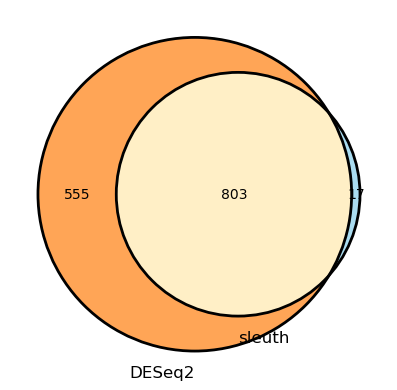

In [19]:
results = matplotlib_venn.venn2(subsets = [x, y], set_labels=['DESeq2', 'sleuth'], set_colors=['tab:orange', 'skyblue'], alpha=0.7)
matplotlib_venn.venn2_circles(subsets=[x, y])  

#matplotlib.pyplot.show()
matplotlib.pyplot.savefig('venn.svg')

In [22]:
common = list(x & y)
print(len(common))
df = pandas.DataFrame(common, columns=['common'])
df.to_csv('my_list.txt', sep='\t', index=False)

803
